# Can I predict tonight's sleep score before going to bed?

The statistics notebook showed what correlates with sleep *after the night
happened*. This one asks the harder, more useful question: using only what is
known **before** the night (bedtime, day of week, recent sleep history,
today's activity), how well can tonight's score be forecast?

Method notes:
- **Time-based split**: train on the first ~80% of nights, test on the last ~20%.
  No shuffling - shuffling time series leaks the future into training.
- **Baselines first**: a model only earns its complexity if it beats the
  naive answers. Baselines: global mean, last-7-nights mean, same-weekday mean.
- Models: Ridge regression (interpretable coefficients), then a small
  RandomForest to check whether non-linearities add anything.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

load_dotenv("../.env")

SURFACE, INK, INK2, BLUE = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6"
RED = "#c25a4a"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

# Features come from the dbt marts layer, not from pandas. See the note below.
engine = create_engine(os.environ["DATABASE_URL"])
df = pd.read_sql("""
    SELECT day, sleep_score, isodow, is_sunday_night, is_weekend_night,
           bedtime_hours, prev_score, prev_sleep_hours, prev_activity_score,
           prev_steps, roll7_score, roll7_nights, days_since_prev_record, follows_gap
    FROM marts.mart_sleep_daily
    ORDER BY day
""", engine, parse_dates=["day"]).set_index("day")
print(len(df), "nights from marts.mart_sleep_daily")

1244 nights from marts.mart_sleep_daily


## Features come from dbt, not from this notebook

Every feature below is a column in `marts.mart_sleep_daily`. That is not
tidiness for its own sake: the same feature logic was duplicated across four
notebooks in pandas, and one version of it was wrong.

`.rolling(7)` in pandas counts **rows**, not days. This dataset is missing 189
calendar days, so "the previous seven nights" stretched up to 34 calendar days
and 311 of 1,244 rolling means were computed over the wrong window, off by as
much as 14 sleep-score points. The mart uses `RANGE BETWEEN INTERVAL '7 days'
PRECEDING AND INTERVAL '1 day' PRECEDING`, so a gap shortens the window instead
of silently widening it, and `roll7_nights` says how many nights each window
actually held.

Two consequences worth naming:

- `days_since_prev_record` is now a feature. `prev_score` means "most recently
  recorded", which after a long gap can be weeks old. Handing a model a stale
  number as if it were last night is a quiet way to mislead it; giving it the
  staleness alongside lets it discount accordingly.
- Nothing here is knowable only after the night. `roll7_score` deliberately
  ends one day before the target, so these stay legitimate pre-bed features.

In [2]:
d = df.copy()
d["is_sunday_night"] = d.is_sunday_night.astype(int)
d["is_weekend_night"] = d.is_weekend_night.astype(int)
d["dow"] = d.isodow - 1  # Monday = 0, so dow 0 is Sunday night

FEATURES = ["bedtime_hours", "is_sunday_night", "is_weekend_night",
            "prev_score", "roll7_score", "prev_sleep_hours",
            "prev_activity_score", "prev_steps", "days_since_prev_record"]
# roll7_nights and follows_gap are not features. They are carried through so the
# error analysis can ask whether the model fails where the data is thin.
CARRY = ["sleep_score", "dow", "roll7_nights", "follows_gap"]
data = d[FEATURES + CARRY].dropna()
print(len(data), "usable nights")
print(f"nights dropped for missing features: {len(d) - len(data)}")

1221 usable nights
nights dropped for missing features: 23


In [3]:
split = int(len(data) * 0.8)
train, test = data.iloc[:split], data.iloc[split:]
print(f"train: {train.index.min().date()} -> {train.index.max().date()}  (n={len(train)})")
print(f"test:  {test.index.min().date()} -> {test.index.max().date()}  (n={len(test)})")

y_tr, y_te = train["sleep_score"], test["sleep_score"]
results = {}

# Baseline 1: global mean of training set
results["global mean"] = mean_absolute_error(y_te, np.full(len(y_te), y_tr.mean()))

# Baseline 2: rolling 7-night mean (already a feature)
results["last-7-nights mean"] = mean_absolute_error(y_te, test["roll7_score"])

# Baseline 3: same-weekday training mean
dow_means = train.groupby("dow")["sleep_score"].mean()
results["same-weekday mean"] = mean_absolute_error(y_te, test["dow"].map(dow_means))

for k, v in results.items():
    print(f"{k:22s} MAE = {v:.2f}")

train: 2022-08-24 -> 2025-11-05  (n=976)
test:  2025-11-06 -> 2026-07-25  (n=245)
global mean            MAE = 9.17
last-7-nights mean     MAE = 9.12
same-weekday mean      MAE = 9.16


In [4]:
X_tr, X_te = train[FEATURES], test[FEATURES]

# Standardize for Ridge so coefficients are comparable
mu, sd = X_tr.mean(), X_tr.std()
ridge = Ridge(alpha=1.0).fit((X_tr - mu) / sd, y_tr)
results["ridge regression"] = mean_absolute_error(y_te, ridge.predict((X_te - mu) / sd))

rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                           random_state=42).fit(X_tr, y_tr)
results["random forest"] = mean_absolute_error(y_te, rf.predict(X_te))

# A third family, so "why linear" is answered by evidence rather than taste
gb = HistGradientBoostingRegressor(max_iter=300, min_samples_leaf=10,
                                   random_state=42).fit(X_tr, y_tr)
results["gradient boosting"] = mean_absolute_error(y_te, gb.predict(X_te))

print(f"{'model':22s} {'MAE':>6s}")
for k, v in sorted(results.items(), key=lambda kv: kv[1]):
    print(f"{k:22s} {v:6.2f}")

model                     MAE
ridge regression         7.64
random forest            7.80
gradient boosting        8.06
last-7-nights mean       9.12
same-weekday mean        9.16
global mean              9.17


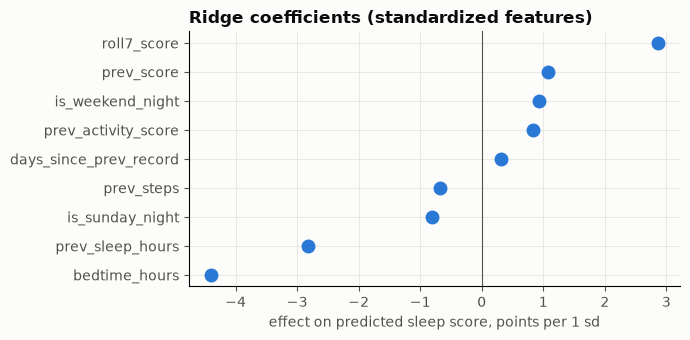

In [5]:
coefs = pd.Series(ridge.coef_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(coefs.values, coefs.index, "o", color=BLUE, markersize=9)
ax.axvline(0, color=INK2, linewidth=0.8)
ax.set_title("Ridge coefficients (standardized features)",
             loc="left", fontweight="bold", color=INK)
ax.set_xlabel("effect on predicted sleep score, points per 1 sd")
plt.tight_layout(); plt.show()

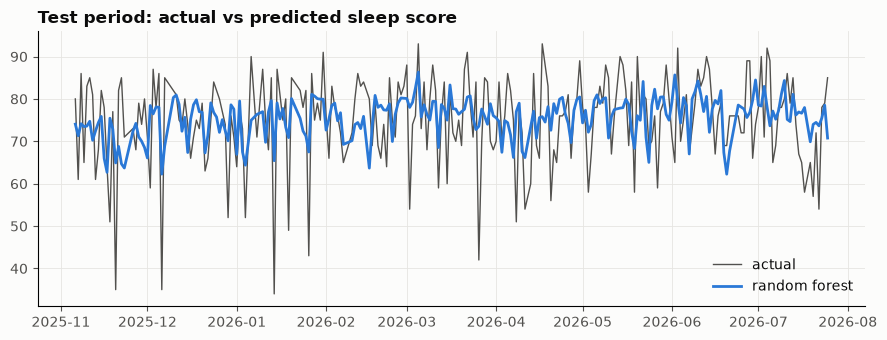

In [6]:
pred = rf.predict(X_te)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(y_te.index, y_te.values, color=INK2, linewidth=1, label="actual")
ax.plot(y_te.index, pred, color=BLUE, linewidth=2, label="random forest")
ax.set_title("Test period: actual vs predicted sleep score",
             loc="left", fontweight="bold", color=INK)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## How much should I trust one number?

MAE 7.64 came from a single split. Two things are missing before that means
anything: an interval around it, and evidence that the split was not lucky.

The interval has to be **paired**. Bootstrapping each model's MAE separately
gives ridge [6.87, 8.46] and the baseline [8.23, 10.04], which overlap, and it
would be easy to conclude the improvement is not real. That comparison is
wrong: both models are scored on the same nights, so their errors are strongly
correlated and the difference is estimated far more precisely than either level.
Resampling the *paired* difference is the right test.

For the split, rolling-origin cross-validation: train on a prefix, test on the
block that follows, expand, repeat. Never shuffled, because shuffling a time
series lets the future leak into training.

In [7]:
# Paired bootstrap on the MAE difference, same nights for both models
pred_ridge = ridge.predict((X_te - mu) / sd)
err_model = np.abs(y_te.values - pred_ridge)
err_base = np.abs(y_te.values - test["roll7_score"].values)

rng = np.random.default_rng(42)
idx = np.arange(len(y_te))
boots = np.array([(err_base[s] - err_model[s]).mean()
                  for s in (rng.choice(idx, idx.size) for _ in range(10_000))])
lo, hi = np.percentile(boots, [2.5, 97.5])
print("PAIRED comparison against the 7-night baseline")
print(f"  improvement {(err_base - err_model).mean():+.2f} MAE points, "
      f"95% CI [{lo:+.2f}, {hi:+.2f}]")
print(f"  model wins in {(boots > 0).mean():.1%} of resamples")

# Rolling-origin cross-validation
def fit_all(a, b):
    m, s = a[FEATURES].mean(), a[FEATURES].std()
    return {
        "ridge": Ridge(alpha=1.0).fit((a[FEATURES] - m) / s, a.sleep_score)
                     .predict((b[FEATURES] - m) / s),
        "forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                     random_state=42).fit(a[FEATURES], a.sleep_score).predict(b[FEATURES]),
        "boosting": HistGradientBoostingRegressor(max_iter=300, min_samples_leaf=10,
                     random_state=42).fit(a[FEATURES], a.sleep_score).predict(b[FEATURES]),
        "7-night baseline": b.roll7_score.values,
    }

folds = []
for k, (i_tr, i_te) in enumerate(TimeSeriesSplit(n_splits=5).split(data), 1):
    a, b = data.iloc[i_tr], data.iloc[i_te]
    maes = {name: mean_absolute_error(b.sleep_score, p) for name, p in fit_all(a, b).items()}
    folds.append({"fold": k, "train_n": len(a),
                  "from": b.index.min().date(), "to": b.index.max().date(),
                  **maes,
                  "ridge_lift_%": (1 - maes["ridge"] / maes["7-night baseline"]) * 100})

cv = pd.DataFrame(folds).set_index("fold")
print()
print(cv.round(2).to_string())
print()
print(cv[["ridge", "forest", "boosting", "7-night baseline"]].agg(["mean", "std"]).round(2).to_string())

PAIRED comparison against the 7-night baseline
  improvement +1.48 MAE points, 95% CI [+0.87, +2.06]
  model wins in 100.0% of resamples



      train_n        from          to  ridge  forest  boosting  7-night baseline  ridge_lift_%
fold                                                                                          
1         206  2023-04-01  2024-01-01  10.40    9.82     11.29              9.34        -11.38
2         409  2024-01-02  2024-09-26   9.56    9.74     10.07             11.11         13.97
3         612  2024-09-27  2025-05-06   9.64    9.52     10.57             11.18         13.78
4         815  2025-05-07  2025-12-21   7.47    7.91      8.85              8.70         14.20
5        1018  2025-12-22  2026-07-25   7.44    7.63      8.00              8.79         15.34

      ridge  forest  boosting  7-night baseline
mean   8.90    8.93      9.76              9.83
std    1.36    1.07      1.33              1.23


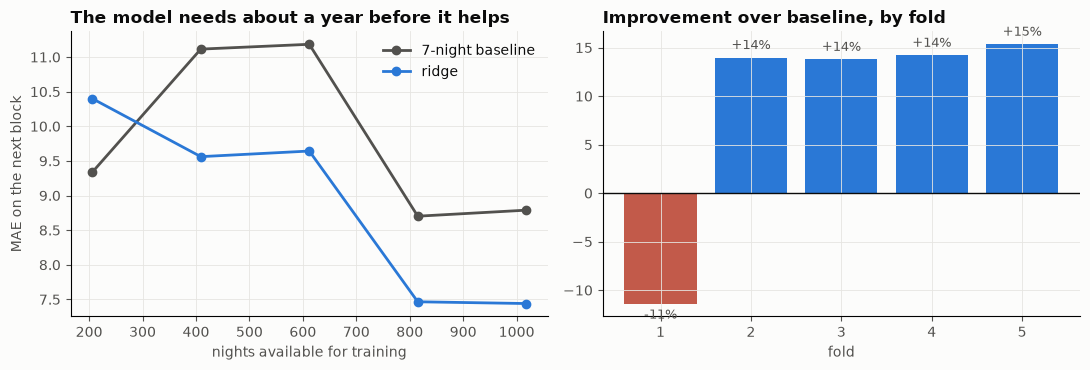

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
for name, colour in [("7-night baseline", INK2), ("ridge", BLUE)]:
    ax.plot(cv.train_n, cv[name], "o-", color=colour, linewidth=2, label=name)
ax.set_xlabel("nights available for training")
ax.set_ylabel("MAE on the next block")
ax.set_title("The model needs about a year before it helps", loc="left",
             fontweight="bold", color=INK)
ax.legend(frameon=False)

ax = axes[1]
ax.bar(cv.index.astype(str), cv["ridge_lift_%"],
       color=[RED if v < 0 else BLUE for v in cv["ridge_lift_%"]])
ax.axhline(0, color=INK, linewidth=1)
for i, v in zip(cv.index, cv["ridge_lift_%"]):
    ax.annotate(f"{v:+.0f}%", (str(i), v), ha="center",
                va="bottom" if v > 0 else "top",
                xytext=(0, 4 if v > 0 else -4), textcoords="offset points",
                color=INK2, fontsize=9)
ax.set_xlabel("fold")
ax.set_title("Improvement over baseline, by fold", loc="left",
             fontweight="bold", color=INK)
plt.tight_layout(); plt.show()

**The single split was the friendliest one.** Fold 1, trained on 206 nights,
is 11% *worse* than doing nothing. From fold 2 onward the improvement is
remarkably stable at +14.0%, +13.8%, +14.2%, +15.3%, and the published 16% is
the most recent fold with the most training data behind it. So the honest claim
is not "16%" and not the 9.5% five-fold average either: **the model needs
roughly a year of history, after which it beats the baseline by about 14%.**

Absolute MAE moves for reasons that have nothing to do with the model. Folds 2
and 3 are worse for *every* method, baseline included, because they cover the
2024 dip when my sleep was genuinely more volatile. That is why the per-fold
lift matters more than the per-fold MAE.

Gradient boosting comes third of three (9.76 mean against ridge 8.90). Two
tree ensembles both losing to a linear model is reasonable evidence that the
relationship really is close to linear, rather than ridge getting lucky once.

## Where does it fail?

An aggregate MAE hides the shape of the errors, and the shape is what decides
whether a model is any use. The only genuinely useful forecast here would be
"tonight is going to be bad, go to bed now", so performance on bad nights is
the number that matters, not performance on average.

In [9]:
t = test.copy()
t["pred"] = pred_ridge
t["err"] = t.sleep_score - t.pred          # negative = over-predicted
t["abs_err"] = t.err.abs()
t["base_abs_err"] = (t.sleep_score - t.roll7_score).abs()

print("SPREAD: does the model commit to anything?")
print(f"  actual    min {t.sleep_score.min():.0f}  max {t.sleep_score.max():.0f}  sd {t.sleep_score.std():.1f}")
print(f"  predicted min {t.pred.min():.0f}  max {t.pred.max():.0f}  sd {t.pred.std():.1f}")
print(f"  the model uses {t.pred.std() / t.sleep_score.std():.0%} of the outcome's spread")

t["bucket"] = pd.cut(t.sleep_score, [0, 60, 70, 80, 101], right=False,
                     labels=["under 60 (bad)", "60-69", "70-79", "80+ (good)"])
by_bucket = t.groupby("bucket", observed=True).agg(
    nights=("sleep_score", "size"), actual=("sleep_score", "mean"),
    predicted=("pred", "mean"), bias=("err", "mean"),
    model_mae=("abs_err", "mean"), base_mae=("base_abs_err", "mean"))
by_bucket["lift_%"] = (1 - by_bucket.model_mae / by_bucket.base_mae) * 100
print()
print(by_bucket.round(2).to_string())

print()
print("CAN IT WARN ME? flagging a night as bad (actual score under 60)")
actual_bad = t.sleep_score < 60
for threshold in [60, 65, 70]:
    flagged = t.pred < threshold
    caught = (flagged & actual_bad).sum()
    recall = caught / actual_bad.sum()
    precision = caught / flagged.sum() if flagged.sum() else float("nan")
    print(f"  flag when predicted < {threshold}: caught {caught}/{actual_bad.sum()} "
          f"(recall {recall:.0%}), precision {precision:.0%}")

print()
print("ERROR BY DATA COMPLETENESS (a full 7-night window vs a gappy one)")
print(t.groupby(t.roll7_nights >= 7, observed=True)
       .agg(nights=("abs_err", "size"), model_mae=("abs_err", "mean"),
            base_mae=("base_abs_err", "mean")).round(2).to_string())

print()
print("SYSTEMATIC BIAS BY NIGHT OF WEEK (negative = over-predicted)")
names = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
dow_tbl = t.groupby("dow", observed=True).agg(nights=("abs_err", "size"),
                                              mae=("abs_err", "mean"), bias=("err", "mean"))
dow_tbl.index = [names[i] for i in dow_tbl.index]
print(dow_tbl.round(2).to_string())

SPREAD: does the model commit to anything?
  actual    min 34  max 93  sd 10.6
  predicted min 45  max 84  sd 4.4
  the model uses 41% of the outcome's spread

                nights  actual  predicted   bias  model_mae  base_mae  lift_%
bucket                                                                       
under 60 (bad)      21   50.95      71.61 -20.66      20.66     24.03   14.01
60-69               42   66.14      73.97  -7.83       7.83      9.88   20.79
70-79               92   74.98      76.15  -1.17       3.48      3.84    9.54
80+ (good)          90   84.77      76.11   8.66       8.76     10.67   17.90

CAN IT WARN ME? flagging a night as bad (actual score under 60)
  flag when predicted < 60: caught 0/21 (recall 0%), precision 0%
  flag when predicted < 65: caught 1/21 (recall 5%), precision 50%
  flag when predicted < 70: caught 11/21 (recall 52%), precision 46%

ERROR BY DATA COMPLETENESS (a full 7-night window vs a gappy one)
              nights  model_mae  base_

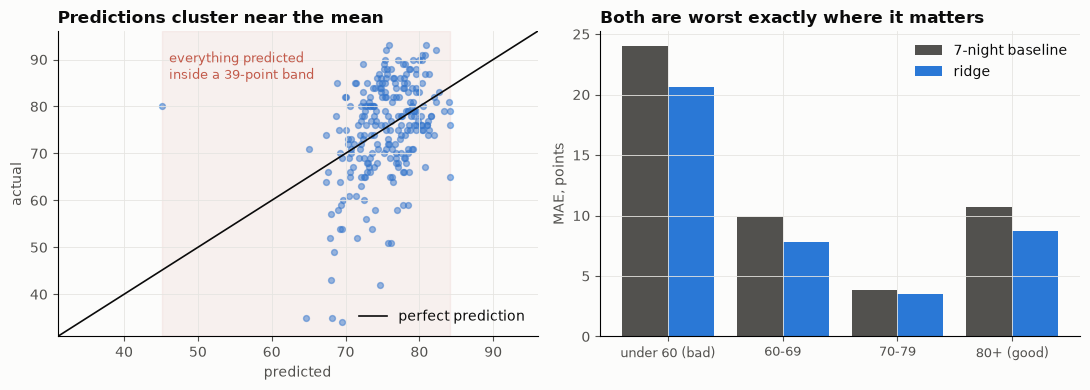

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.scatter(t.pred, t.sleep_score, s=18, alpha=0.5, color=BLUE)
lims = [t.sleep_score.min() - 3, t.sleep_score.max() + 3]
ax.plot(lims, lims, color=INK, linewidth=1.2, label="perfect prediction")
ax.axvspan(t.pred.min(), t.pred.max(), color=RED, alpha=0.07)
ax.annotate(f"everything predicted\ninside a {t.pred.max()-t.pred.min():.0f}-point band",
            (t.pred.min() + 1, lims[1] - 4), fontsize=9, color=RED, va="top")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Predictions cluster near the mean", loc="left",
             fontweight="bold", color=INK)
ax.legend(frameon=False, loc="lower right")

ax = axes[1]
x = np.arange(len(by_bucket))
ax.bar(x - 0.2, by_bucket.base_mae, width=0.4, color=INK2, label="7-night baseline")
ax.bar(x + 0.2, by_bucket.model_mae, width=0.4, color=BLUE, label="ridge")
ax.set_xticks(x); ax.set_xticklabels(by_bucket.index, fontsize=9)
ax.set_ylabel("MAE, points")
ax.set_title("Both are worst exactly where it matters", loc="left",
             fontweight="bold", color=INK)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**The model predicts roughly the same thing every night.** Its predictions have
a standard deviation of 4.4 against the outcome's 10.6, so it uses 41% of the
available spread and never leaves a 39-point band while reality spans 59. That
is what a well-regularised model does when the features are weakly informative,
and it is the honest reason the MAE looks respectable.

**It cannot see a bad night coming, which was the whole point.** On the 21
nights scoring under 60 it predicts 71.6 on average against an actual 51.0,
over-predicting by nearly 21 points. Asked to flag those nights it catches **none of
them** at any sensible threshold: predicting under 60 flags nothing at all, and
loosening to under 70 catches half while being wrong more often than right.
There is no operating point where this is a useful warning.

The 14% improvement is real, and it comes almost entirely from being less wrong
than the baseline at the extremes rather than from anticipating anything. In the
70-79 band where most nights live, the gain shrinks to 9.5%, against 14 to 21%
in the tails.

**Two more specific weaknesses**, both actionable:

- Errors are 45% larger when the trailing week is incomplete, 10.35 against 7.15
  MAE. The baseline degrades too, so this is thin data rather than a modelling
  flaw, but it means predictions after a break deserve less trust.
- Day-of-week bias survives having day-of-week features. Sunday nights are
  over-predicted by 2.6 points and Friday nights under-predicted by 3.8. Two
  binary dummies cannot express the shape, so this is the clearest place a
  better specification would pay.

**Not testable here:** every night in the test window follows a logged night, so
the effect of a long gap on prediction quality cannot be measured on this split.

## Conclusions

- **The model needs about a year of history, then beats the baseline by roughly
  14%.** Not the 16% a single split suggests, and not the 9.5% a five-fold
  average suggests either. Fold 1, with 206 training nights, is 11% *worse* than
  doing nothing; every fold after that lands between +13.8% and +15.3%. The
  improvement on the held-out split is +1.48 MAE points with a paired 95% CI of
  [+0.87, +2.06], so it is real rather than noise.
- **The linear model wins, and now on evidence.** Ridge 7.64, random forest
  7.80, gradient boosting 8.06 on the hold-out, with the same ordering across
  cross-validation. Two independent tree ensembles losing to a linear model is
  reasonable grounds for believing the relationship is close to linear. The
  forest previously looked better only because bedtime was being read in UTC
  (see notebook 01), which flattened the strongest signal and left curvature for
  the trees to chase.
- **But it cannot do the one thing worth doing.** Predictions occupy 41% of the
  outcome's spread and never leave a 39-point band. On the 21 nights scoring
  under 60 it predicts 71.6 against an actual 51.0 and flags none of them at any
  usable threshold. The MAE gain comes from being less wrong at the extremes, not
  from anticipating them. As a warning system this does not work, and the
  aggregate metric hides that completely.
- **Bedtime is still the biggest controllable lever**, consistent with the
  timing finding in the README, and that remains the actionable result from this
  notebook. The model is evidence about which lever matters, not a useful
  forecast.
- **What would actually help**, in order of expected value: the variables that
  were never recorded (alcohol, caffeine, illness, work stress), a specification
  that can express day-of-week shape rather than two dummies, and
  `marts.mart_workout_recovery` for training load, though a first look there
  shows no dose-response. A model is only as good as what was recorded, and the
  things that most plausibly ruin a night are exactly the things I never logged.